In [1]:
import pandas as pd
import os

In [2]:
base_df = pd.read_csv('../data/data_final_with_aadt_and_vulnerability.csv')

In [9]:
base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]
scenario_results = {}

#loop through 12 scenarios
for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'

    scenario_df = pd.read_csv(file_path)

    merged_df = pd.merge(
        scenario_df[['Seed', 'Total_Delay']],
        base_subset,
        left_on='Seed',
        right_on='id'
    ).drop(columns=['Seed'])[['id', 'Total_Delay', 'avg_truck_AADT', 'lat', 'lon']]

    scenario_results[f'scenario_{i}'] = merged_df

In [21]:
scenario_df.head()

,Seed,Total_Delay
0,100009,2149.872474
1,100011,2166.222732
2,100015,2121.920404
3,100053,4324.460246
4,100057,4235.461046


In [11]:
#seperate df for every scenario
for i in range(12):
    globals()[f'df_{i}'] = scenario_results[f'scenario_{i}']

df_0.head()

,id,Total_Delay,avg_truck_AADT,lat,lon
0,100009,2198.528386,2872.333333,23.696400,90.535099
1,100015,2218.461124,2872.333333,23.692360,90.540918
2,100057,4479.450661,2082.666667,23.586318,90.634509
3,100061,11113.319871,2082.666667,23.571631,90.645416
4,100077,4330.177641,2261.666667,23.539391,90.678458


In [22]:
df_11.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,impact_scaled,scenario
0,100009,2149.872474,2872.333333,23.696400,90.535099,6.175150e+06,0.239335,Scenario 11
1,100011,2166.222732,2872.333333,23.694391,90.537574,6.222114e+06,0.241157,Scenario 11
2,100015,2121.920404,2872.333333,23.692360,90.540918,6.094863e+06,0.236218,Scenario 11
3,100053,4324.460246,2082.666667,23.592982,90.627970,9.006409e+06,0.349231,Scenario 11
4,100057,4235.461046,2082.666667,23.586318,90.634509,8.821054e+06,0.342037,Scenario 11


In [14]:
for i in range(12):
    df = scenario_results[f'scenario_{i}']

    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']

    mi = merged_df['impact_raw'].min()
    ma = merged_df['impact_raw'].max()
    merged_df['impact_scaled'] = (merged_df['impact_raw'] - mi) / (ma - mi)

    scenario_results[f'scenario_{i}'] = merged_df
    globals()[f'df_{i}'] = merged_df

print("Check: df_0 heeft nu de kolommen:", df_0.columns.tolist())

Check: df_0 heeft nu de kolommen: ['id', 'Total_Delay', 'avg_truck_AADT', 'lat', 'lon', 'impact_raw', 'impact_scaled']


In [15]:
df_0.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,impact_scaled
0,100009,2149.872474,2872.333333,23.696400,90.535099,6.175150e+06,0.239335
1,100011,2166.222732,2872.333333,23.694391,90.537574,6.222114e+06,0.241157
2,100015,2121.920404,2872.333333,23.692360,90.540918,6.094863e+06,0.236218
3,100053,4324.460246,2082.666667,23.592982,90.627970,9.006409e+06,0.349231
4,100057,4235.461046,2082.666667,23.586318,90.634509,8.821054e+06,0.342037


In [16]:
df_11.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,impact_scaled
0,100009,2149.872474,2872.333333,23.696400,90.535099,6.175150e+06,0.239335
1,100011,2166.222732,2872.333333,23.694391,90.537574,6.222114e+06,0.241157
2,100015,2121.920404,2872.333333,23.692360,90.540918,6.094863e+06,0.236218
3,100053,4324.460246,2082.666667,23.592982,90.627970,9.006409e+06,0.349231
4,100057,4235.461046,2082.666667,23.586318,90.634509,8.821054e+06,0.342037


In [20]:
df_5.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,impact_scaled,scenario
0,100009,2149.872474,2872.333333,23.696400,90.535099,6.175150e+06,0.239335,Scenario 11
1,100011,2166.222732,2872.333333,23.694391,90.537574,6.222114e+06,0.241157,Scenario 11
2,100015,2121.920404,2872.333333,23.692360,90.540918,6.094863e+06,0.236218,Scenario 11
3,100053,4324.460246,2082.666667,23.592982,90.627970,9.006409e+06,0.349231,Scenario 11
4,100057,4235.461046,2082.666667,23.586318,90.634509,8.821054e+06,0.342037,Scenario 11


In [28]:
import pandas as pd

base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]
scenario_results = {}

# STAP 1: Eerst alle data verzamelen en de ruwe impact berekenen
all_dfs = []
for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'
    scenario_df = pd.read_csv(file_path)

    merged_df = pd.merge(
        scenario_df[['Seed', 'Total_Delay']],
        base_subset,
        left_on='Seed',
        right_on='id'
    ).drop(columns=['Seed'])[['id', 'Total_Delay', 'avg_truck_AADT', 'lat', 'lon']]

    # Bereken de ruwe impact (Delay * Trucks)
    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']
    merged_df['scenario_id'] = i  # Handig om later te weten welk scenario dit was

    all_dfs.append(merged_df)

# STAP 2: Bereken de globale Min en Max over alle 12 scenario's heen
combined_data = pd.concat(all_dfs)
global_min = combined_data['impact_raw'].min()
global_max = combined_data['impact_raw'].max()

# STAP 3: De scaling toepassen en de resultaten opslaan
for i, df in enumerate(all_dfs):
    # Pas de scaling toe op basis van de globale uitersten
    df['impact_scaled'] = (df['impact_raw'] - global_min) / (global_max - global_min)

    # Sorteer zodat de meest kritieke punten (top 20) bovenaan staan
    #df = df.sort_values(by='impact_scaled', ascending=False)

    # Sla op in dictionary en als losse variabelen (df_0, df_1, etc.)
    scenario_results[f'scenario_{i}'] = df
    globals()[f'df_{i}'] = df

print(f"Check: df_0 is klaar. Globale max was {global_max:.2f}")
print(df_0[['id', 'impact_raw', 'impact_scaled']].head(5))

Check: df_0 is klaar. Globale max was 32100463.22
       id    impact_raw  impact_scaled
0  100009  6.314906e+06       0.196493
1  100015  6.372160e+06       0.198277
2  100057  9.329203e+06       0.290422
3  100061  2.314534e+07       0.720948
4  100077  9.793418e+06       0.304887


In [29]:
df_0.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,scenario_id,impact_scaled
0,100009,2198.528386,2872.333333,23.696400,90.535099,6.314906e+06,0,0.196493
1,100015,2218.461124,2872.333333,23.692360,90.540918,6.372160e+06,0,0.198277
2,100057,4479.450661,2082.666667,23.586318,90.634509,9.329203e+06,0,0.290422
3,100061,11113.319871,2082.666667,23.571631,90.645416,2.314534e+07,0,0.720948
4,100077,4330.177641,2261.666667,23.539391,90.678458,9.793418e+06,0,0.304887


In [30]:
df_11.head()

,id,Total_Delay,avg_truck_AADT,lat,lon,impact_raw,scenario_id,impact_scaled
0,100009,2149.872474,2872.333333,23.696400,90.535099,6.175150e+06,11,0.192138
1,100011,2166.222732,2872.333333,23.694391,90.537574,6.222114e+06,11,0.193601
2,100015,2121.920404,2872.333333,23.692360,90.540918,6.094863e+06,11,0.189636
3,100053,4324.460246,2082.666667,23.592982,90.627970,9.006409e+06,11,0.280363
4,100057,4235.461046,2082.666667,23.586318,90.634509,8.821054e+06,11,0.274587


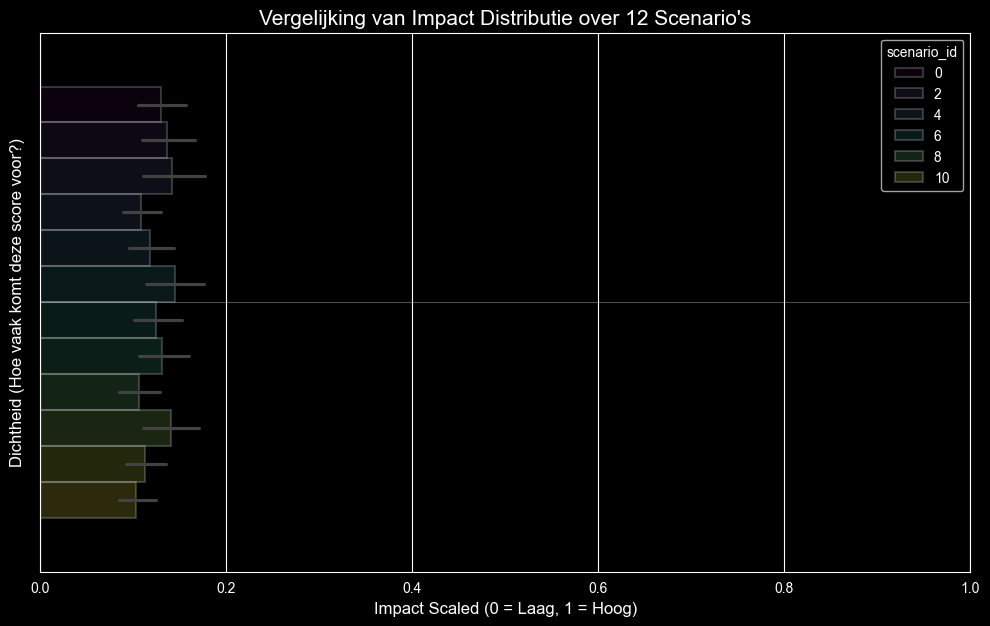

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Verzamel alle data in één dataframe voor Seaborn
df_plot = pd.concat([scenario_results[f'scenario_{i}'] for i in range(12)])

# 2. Maak de plot
plt.figure(figsize=(12, 7))

# We gebruiken 'hue' om de 12 scenario's te onderscheiden
# 'fill=True' geeft het bar-effect, 'alpha' regelt de transparantie
sns.barplot(
    data=df_plot,
    x='impact_scaled',
    hue='scenario_id',
    fill=True,
    palette="viridis",
    alpha=0.2,      # Transparantie zodat je de overlap ziet
    linewidth=1.5
)

# 3. Styling
plt.title('Vergelijking van Impact Distributie over 12 Scenario\'s', fontsize=15)
plt.xlabel('Impact Scaled (0 = Laag, 1 = Hoog)', fontsize=12)
plt.ylabel('Dichtheid (Hoe vaak komt deze score voor?)', fontsize=12)
plt.xlim(0, 1) # We weten dat het tussen 0 en 1 ligt
plt.grid(axis='y', alpha=0.3)

plt.show()

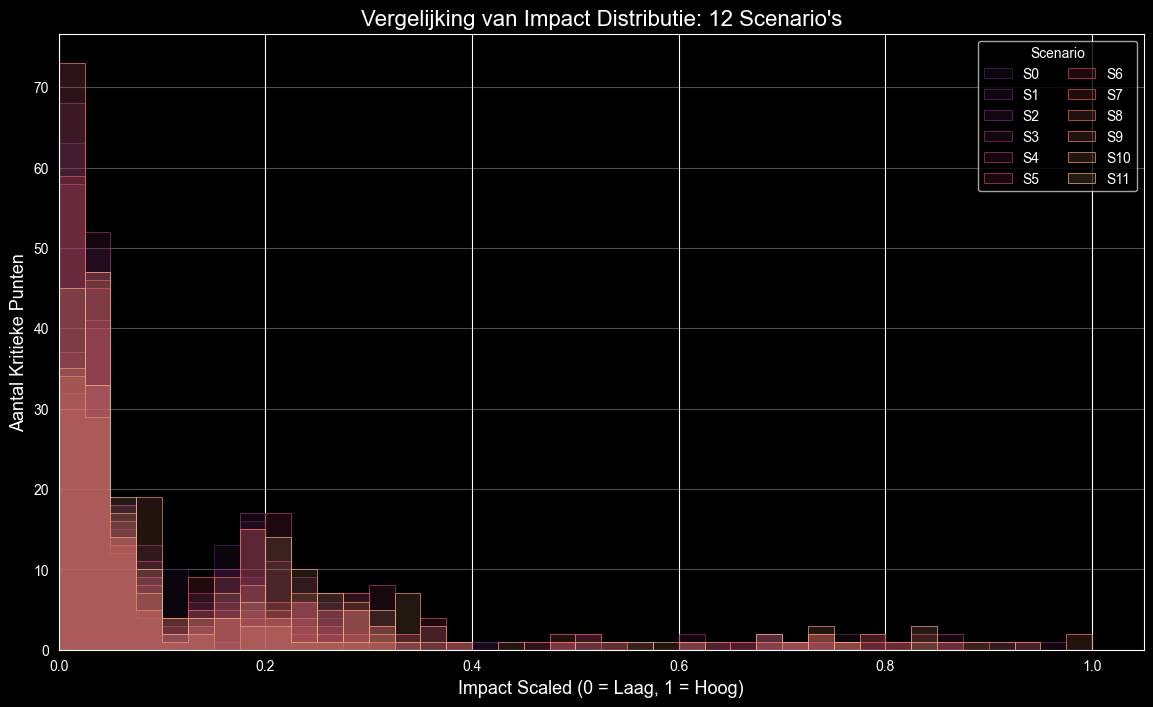

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Verzamel alle data in één dataframe voor Seaborn
df_plot = pd.concat([scenario_results[f'scenario_{i}'] for i in range(12)])

# 2. Maak de plot
plt.figure(figsize=(14, 8))

# We gebruiken sns.histplot met specifieke instellingen voor overlap:
sns.histplot(
    data=df_plot,
    x='impact_scaled',
    hue='scenario_id',       # Voor de 12 verschillende kleuren
    element="step",         # Zorgt ervoor dat de balken niet direct op elkaar liggen, maar 'trappen' vormen
    stat="count",           # 'count' laat het aantal bruggen per impact-groep zien
    alpha=0.15,             # Hoge transparantie zodat je de overlap ziet
    linewidth=0.5,
    common_norm=False,      # Zorgt ervoor dat elk scenario zijn eigen schaal heeft op de y-as
    palette="flare",        # Een mooi kleurverloop
    fill=True
)

# 3. Styling
plt.title('Vergelijking van Impact Distributie: 12 Scenario\'s', fontsize=16)
plt.xlabel('Impact Scaled (0 = Laag, 1 = Hoog)', fontsize=13)
plt.ylabel('Aantal Kritieke Punten', fontsize=13)
plt.xlim(0, 1.05)       # De schaal loopt van 0 tot 1
plt.grid(axis='y', alpha=0.3)

# 4. Legenda verduidelijken
plt.legend(title='Scenario', labels=[f'S{i}' for i in range(12)], fontsize=10, ncol=2)

plt.show()

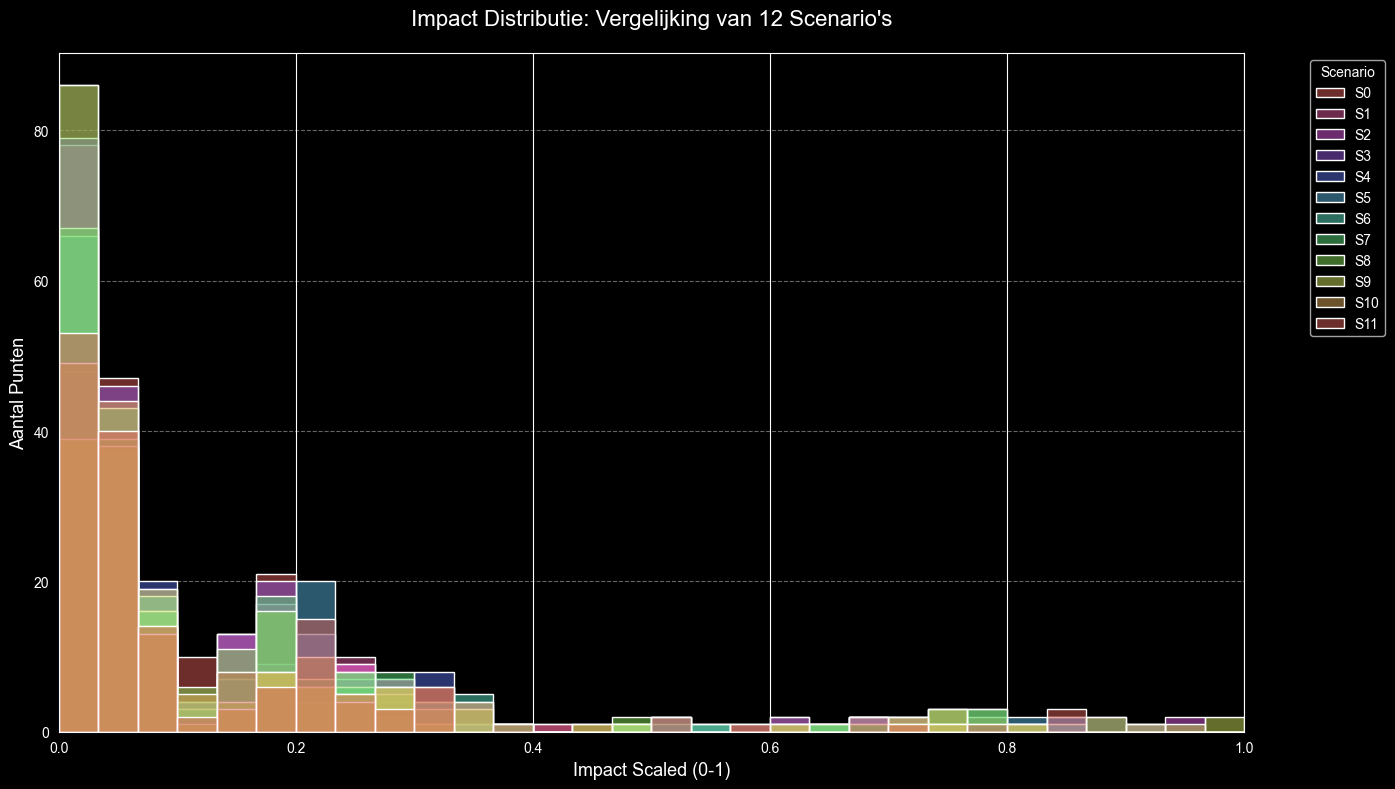

In [39]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Verzamel data
df_plot = pd.concat([scenario_results[f'scenario_{i}'] for i in range(12)])

# 2. Maak de plot
plt.figure(figsize=(14, 8))

sns.histplot(
    data=df_plot,
    x='impact_scaled',
    hue='scenario_id',
    element="bars",         # Dit zorgt voor volledig ingekleurde balken
    multiple="layer",       # Dit legt de balken over elkaar heen (niet gestapeld)
    stat="count",
    alpha=0.5,              # Transparantie is essentieel om de overlap te zien
    palette="hls",        # Tab20 heeft 20 duidelijke, verschillende kleuren
    edgecolor=None,         # Geen zwarte lijntjes om de balken voor een cleaner effect
    bins=30                 # Hoeveelheid balkjes; pas dit aan voor meer/minder detail
)

# 3. Styling
plt.title('Impact Distributie: Vergelijking van 12 Scenario\'s', fontsize=16, pad=20)
plt.xlabel('Impact Scaled (0-1)', fontsize=13)
plt.ylabel('Aantal Punten', fontsize=13)
plt.xlim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Legenda netjes buiten de plot zetten als er te veel overlap is
plt.legend(title='Scenario', bbox_to_anchor=(1.05, 1), loc='upper left', labels=[f'S{i}' for i in range(12)])
plt.tight_layout()

plt.show()